In [1]:
import pandas as pd
import anndata as ad
import scanpy as sc
import numpy as np

import os
import sys

import seaborn as sns
import seaborn.objects as so
import matplotlib.pyplot as plt
from plotnine import *
from tqdm import tqdm
from scipy import stats
from statsmodels.stats.multitest import multipletests

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import logging

logging.basicConfig(format="[%(asctime)s] %(levelname)s:%(name)s: %(message)s", stream=sys.stdout)
logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)


In [2]:
logger.info(f"Load adata...")
adata_path = "/g/stegle/schrod/data/T_Cell/promoter_single_guide_hvg.h5ad"
figure_path = "/g/stegle/schrod/code/TCell/plots/promoter"
adata = ad.read_h5ad(os.path.join(adata_path))


[2026-02-16 14:51:23,506] INFO:__main__: Load adata...


In [3]:
def get_efficiancy(adata, target_key = "guide", no_target_key = "NO-TARGET"):
    all_targets = adata.obs[target_key].unique()
    all_targets = [t for t in all_targets if t != no_target_key] # remove no-target key from list of targets
    
    results = {}
    adata_control = adata[adata.obs[target_key] == no_target_key]
    
    # Calculate control statistics
    control_X = adata_control.X
    control_sum = np.array(control_X.sum(axis=0)).flatten()
    control_sum_sq = (np.array(control_X.todense())** 2).sum(axis=0).flatten()
    n_control = adata_control.shape[0]
    control_mean = control_sum / n_control
    
    for guide in tqdm(all_targets):
        gene = '-'.join(guide.split("-")[1:-1])  # Extract gene name from guide name
        if not np.isin(gene, adata.var_names):
            logger.warning(f"Gene {gene} for {guide} not found in adata.var_names. Skipping.")
            continue
        gene_idx = np.argwhere(adata.var_names == gene)[0][0]
        adata_target = adata[adata.obs[target_key] == guide]
        
        # Get target expression for this gene
        data_tmp = np.array(adata_target[:, gene].X.todense()).flatten()
        
        # Calculate target statistics
        target_sum = np.array(data_tmp).sum()
        target_sum_sq = (np.array(data_tmp) ** 2).sum()
        n_cells = adata_target.shape[0]
        
        # Calculate means
        control_mean_gene = control_mean[gene_idx]
        target_mean = target_sum / n_cells if n_cells > 0 else 0
        fraction = target_mean / control_mean_gene if control_mean_gene > 0 else 0
        
        # Calculate standard deviations
        target_std = np.sqrt((target_sum_sq - target_sum**2 / n_cells) / (n_cells - 1)) if n_cells > 1 else 100
        target_std = 0.01 if target_std == 0 else target_std
        
        control_sum_gene = control_sum[gene_idx]
        control_sum_sq_gene = control_sum_sq[gene_idx]
        control_std = np.sqrt((control_sum_sq_gene - control_sum_gene**2 / n_control) / (n_control - 1)) if n_control > 1 else 100
        control_std = 0.01 if control_std == 0 else control_std
        
        results[guide] = {
            'gene': gene,
            'control_mean': control_mean_gene,
            'control_std': control_std,
            'n_control': n_control,
            'target_sum': target_sum,
            'target_sum_sq': target_sum_sq,
            'n_cells': n_cells,
            'target_mean': target_mean,
            'target_std': target_std,
            'fraction': fraction
        }
    
    df_results = pd.DataFrame(results).T
    df_results = df_results.reset_index()
    df_results.columns = ['guide', 'gene', 'control_mean', 'control_std', 'n_control', 'target_sum', 'target_sum_sq', 'n_cells', 'target_mean', 'target_std', 'fraction']
    
    return df_results


guides = adata.obs.guide.astype(str).copy()
guides[adata.obs.target == "NO-TARGET"] = "NO-TARGET"
adata.obs["guides_with_NTC"] = guides

res = get_efficiancy(adata, target_key = "guides_with_NTC", no_target_key = "NO-TARGET")



 14%|█████████████▏                                                                                  | 2843/20754 [02:20<14:47, 20.18it/s]

[2026-02-16 14:59:01,465] WARNING:__main__: Gene PSMB8-PSMB8-AS1 for GUIDE-PSMB8-PSMB8-AS1-1 not found in adata.var_names. Skipping.


 17%|████████████████▏                                                                               | 3508/20754 [02:53<14:13, 20.20it/s]

[2026-02-16 14:59:34,386] WARNING:__main__: Gene FAM72C-FAM72D for GUIDE-FAM72C-FAM72D-1 not found in adata.var_names. Skipping.


 28%|██████████████████████████▉                                                                     | 5816/20754 [05:58<12:12, 20.39it/s]

...

 49%|██████████████████████████████████████████████▉                                                | 10245/20754 [10:43<08:35, 20.37it/s]

[2026-02-16 15:07:24,839] WARNING:__main__: Gene FAM72C-FAM72D for GUIDE-FAM72C-FAM72D-2 not found in adata.var_names. Skipping.


 53%|██████████████████████████████████████████████████▏                                            | 10953/20754 [11:18<08:02, 20.32it/s]

[2026-02-16 15:07:59,699] WARNING:__main__: Gene ARHGAP4-NAA10 for GUIDE-ARHGAP4-NAA10-1 not found in adata.var_names. Skipping.


100%|███████████████████████████████████████████████████████████████████████████████████████████████| 20754/20754 [19:27<00:00, 17.78it/s]


In [4]:
# Rename columns to match expected format for testing
ttest_df = res.rename(columns={
    'target_mean': 'guide_mean_expr',
    'target_std': 'guide_std_expr',
    'n_cells': 'guide_n',
    'control_mean': 'ntc_mean_expr',
    'control_std': 'ntc_std_expr',
    'n_control': 'ntc_n'
})

# Calculate Welch's t-test for each row
t_stats = []
p_values = []
for _, row in ttest_df.iterrows():
    t_stat, p_value = stats.ttest_ind_from_stats(
        row['guide_mean_expr'], row['guide_std_expr'], row['guide_n'],
        row['ntc_mean_expr'], row['ntc_std_expr'], row['ntc_n'],
        equal_var=False)
    t_stats.append(t_stat)
    p_values.append(p_value)

ttest_df['t_statistic'] = t_stats
ttest_df['p_value'] = p_values

# Compute Benjamini-Hochberg adjusted p-values
valid_pvals = ttest_df['p_value'].dropna()
_, adj_pvals, _, _ = multipletests(valid_pvals, method='fdr_bh')
ttest_df.loc[valid_pvals.index, 'adj_p_value'] = adj_pvals
ttest_df['signif_knockdown'] = (ttest_df['adj_p_value'] < 0.1) & (ttest_df['t_statistic'] < 0)
ttest_df['adj_p_value'] = np.where(ttest_df['adj_p_value'] < 1e-16, 1e-16, ttest_df['adj_p_value'])



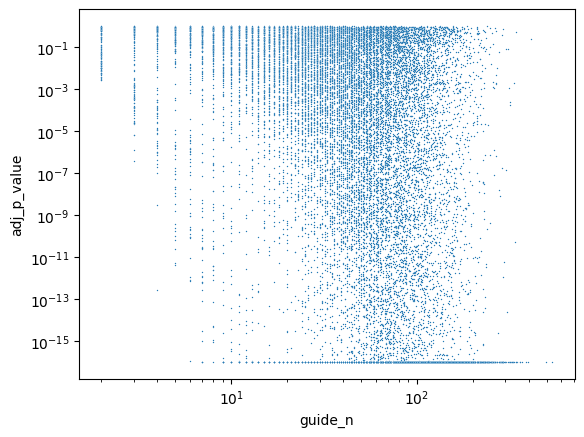

In [ ]:
sns.scatterplot(data=ttest_df, x='guide_n', y='adj_p_value', s=1);
plt.xscale('log')
plt.yscale('log')

In [7]:
# Add perturbed_gene_id column (same as gene name in this dataset)
ttest_df['perturbed_gene_id'] = ttest_df['gene']



[2026-02-16 15:17:52,476] INFO:__main__: Saved figure to /g/stegle/schrod/code/TCell/plots/final/Knockdonw_per_guide_following_Marson.pdf


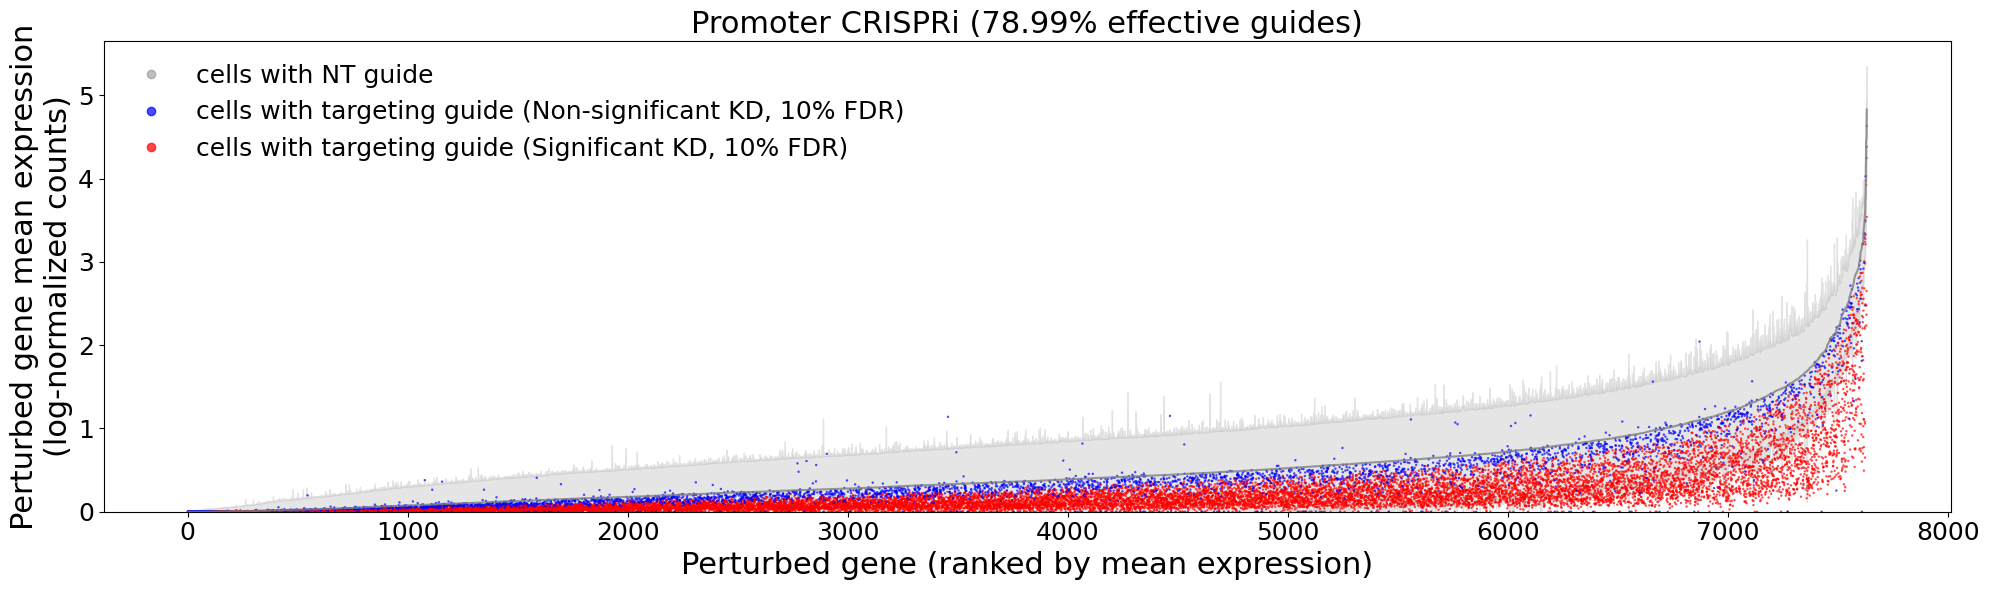

In [8]:
def plot_expression_rank(df, ax, title, save_path = None):
    # Get unique perturbed genes and their mean NTC expression
    gene_ntc_means = df.groupby('perturbed_gene_id')['ntc_mean_expr'].mean()
    gene_ntc_std = df.groupby('perturbed_gene_id')['ntc_std_expr'].mean()
    
    # Rank the perturbed genes by their mean NTC expression
    gene_ranks = gene_ntc_means.rank()
    
    # Map the gene ranks back to the original dataframe
    df['rank'] = df['perturbed_gene_id'].map(gene_ranks)

    # Create a per-gene dataframe for plotting control line (avoid duplicates from multiple guides)
    gene_control_df = pd.DataFrame({
        'rank': gene_ranks.values.astype(float),
        'ntc_mean_expr': gene_ntc_means.values.astype(float),
        'ntc_std_expr': gene_ntc_std.values.astype(float)
    }).sort_values('rank')
    
    # Plot mean NTC expression as a line with shaded area for std
    ax.plot(gene_control_df['rank'].values, gene_control_df['ntc_mean_expr'].values, 
            color='grey', 
            alpha=0.8, 
            label='NT control cells (mean ± std)')
    ax.fill_between(gene_control_df['rank'].values,
                   gene_control_df['ntc_mean_expr'].values - gene_control_df['ntc_std_expr'].values,
                   gene_control_df['ntc_mean_expr'].values + gene_control_df['ntc_std_expr'].values,
                   color='grey',
                   alpha=0.2)

    # Color points based on significance
    sns.scatterplot(
        data=df, 
        y='guide_mean_expr', 
        x='rank',
        s=3, 
        hue='signif_knockdown',
        palette={True: 'red', False: 'blue'},
        hue_order=[True, False],
        legend=False,
        alpha=0.7,
        linewidth=0,
        ax=ax,
        rasterized=True)

    # Add legend
    ax.legend([plt.Line2D([0], [0], marker='o', color='grey', linestyle='', alpha=0.5),
               plt.Line2D([0], [0], marker='o', color='blue', linestyle='', alpha=0.7),
               plt.Line2D([0], [0], marker='o', color='red', linestyle='', alpha=0.7)],
              ['cells with NT guide', 'cells with targeting guide (Non-significant KD, 10% FDR)', 'cells with targeting guide (Significant KD, 10% FDR)'],
              loc='upper left', frameon=False, fontsize=18)
    ax.set_ylim(0)
    ax.set_xlabel('Perturbed gene (ranked by mean expression)', fontsize=22)
    ax.set_ylabel('Perturbed gene mean expression\n(log-normalized counts)', fontsize=22)
    ax.tick_params(axis='both', which='major', labelsize=18)
    ax.set_title(title, fontsize=22)
    if save_path is not None:
        plt.savefig(save_path)
        logger.info(f"Saved figure to {save_path}")


# Create figure with 1 subplot for promoter data
fig, ax = plt.subplots(1, 1, figsize=(20, 6))

# Calculate percentage of effective guides
pct_effective = np.round((ttest_df.signif_knockdown.value_counts().get(True, 0)/ttest_df.shape[0])*100, 2)

# Plot
plot_expression_rank(ttest_df, ax, f'Promoter CRISPRi ({pct_effective}% effective guides)', save_path="/g/stegle/schrod/code/TCell/plots/final/Knockdonw_per_guide_following_Marson.pdf")
plt.tight_layout()
plt.show()



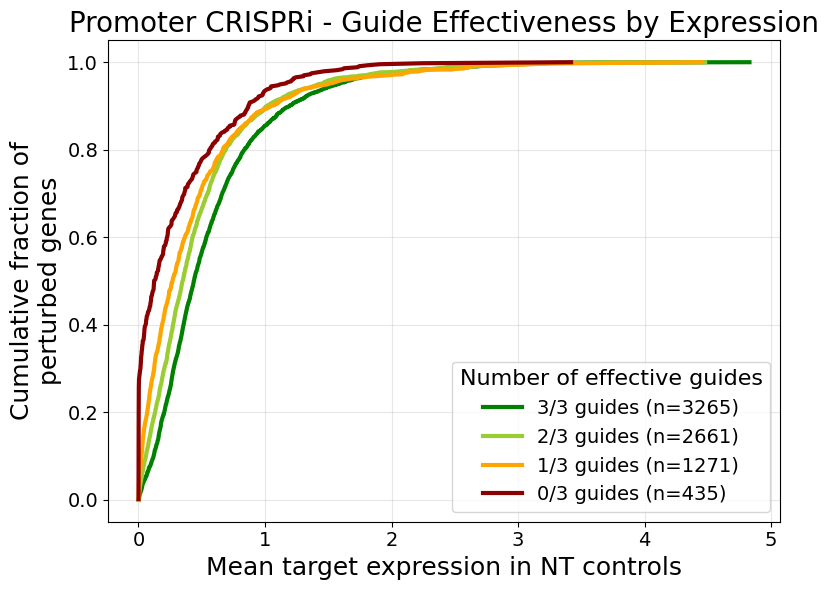

In [9]:
# Cumulative distribution plot showing guide effectiveness per gene
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

def plot_cumulative_dist(df, ax, title):
    # Aggregate by gene: count significant knockdown guides per gene
    pl_df = df.groupby('perturbed_gene_id').agg({
        'ntc_mean_expr': 'mean',
        'signif_knockdown': 'sum'
    })
    # Cap at 3 since we have 3 guides per gene
    pl_df['signif_knockdown'] = np.where(pl_df['signif_knockdown'] > 3, 3, pl_df['signif_knockdown'])

    colors = {3: 'green', 2: 'yellowgreen', 1: 'orange', 0: 'darkred'}
    for knockdown in sorted(pl_df['signif_knockdown'].unique(), reverse=True):
        subset = pl_df[pl_df['signif_knockdown'] == knockdown]
        x = np.sort(subset['ntc_mean_expr'])
        y = np.arange(1, len(x) + 1) / len(x)
        ax.plot(x, y, 
                label=f'{int(knockdown)}/3 guides (n={len(subset)})', 
                linewidth=3,
                color=colors[knockdown])

    ax.set_xlabel('Mean target expression in NT controls', fontsize=18)
    ax.set_ylabel('Cumulative fraction of\nperturbed genes', fontsize=18)
    ax.legend(title='Number of effective guides', fontsize=14, title_fontsize=16, loc='lower right')
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.set_title(title, fontsize=20)
    save_path = "/g/stegle/schrod/code/TCell/plots/final/Knockdown_per_guide.pdf"
    plt.savefig(save_path)

plot_cumulative_dist(ttest_df, ax, f'Promoter CRISPRi - Guide Effectiveness by Expression')

plt.tight_layout()
plt.show()

